In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import numpy as np
import pandas as pd
import librosa
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.multioutput import MultiOutputClassifier
import matplotlib.pyplot as plt

In [2]:
sample_rate = 22050
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
sample_rate = 22050
times = 4
audio_files_meta = "metadata.csv"

In [3]:
df = pd.read_csv(audio_files_meta)
augmented_df = pd.read_csv(augmented_meta)

In [4]:
def extract_features(file_path):
    nmfcc = 13
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)
    mfcc   = librosa.feature.mfcc(y=y, sr=sample_rate, n_mfcc=nmfcc)
    chroma = librosa.feature.chroma_stft(S=np.abs(librosa.stft(y)), sr=sample_rate)
    rms    = librosa.feature.rms(y=y)

    spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sample_rate)
    zero_crossing = librosa.feature.zero_crossing_rate(y)
    return np.hstack([
        mfcc.mean(axis=1), mfcc.std(axis=1),
        chroma.mean(axis=1), chroma.std(axis=1),
        rms.mean(), rms.std(),
        spectral_centroid.mean(), spectral_centroid.std(),
        zero_crossing.mean(), zero_crossing.std()
    ])

In [5]:
X, y_emotion_raw, y_intensity_raw, y_gender_raw = [], [], [], []

for _, row in augmented_df.iterrows():
    folder = out_dir if row["augmentation"] != "original" else in_dir
    if "wav" in row["file_name"]:
      path   = os.path.join(folder, row["file_name"])
    else:
      path   = os.path.join(folder, row["file_name"]+".wav")

    X.append(extract_features(path))
    y_emotion_raw.append(row["emotion"])
    y_intensity_raw.append(row["intensity"])
    y_gender_raw.append(row["gender"])

X = np.array(X)
y_emotion_raw = np.array(y_emotion_raw)
y_intensity_raw = np.array(y_intensity_raw)
y_gender_raw = np.array(y_gender_raw)

print(f"Feature matrix: {X.shape}")
print(f"Emotion labels: {np.unique(y_emotion_raw)}")
print(f"Intensity labels: {np.unique(y_intensity_raw)}")
print(f"Gender labels: {np.unique(y_gender_raw)}")

emotion_encoder = LabelEncoder()
intensity_encoder = LabelEncoder()
gender_encoder = LabelEncoder()

y_emotion = emotion_encoder.fit_transform(y_emotion_raw)
y_intensity = intensity_encoder.fit_transform(y_intensity_raw)
y_gender = gender_encoder.fit_transform(y_gender_raw)

y = np.column_stack([y_emotion, y_intensity, y_gender])

# Extract groups from original stem to prevent leakage from augmentation
augmented_df['original_stem'] = augmented_df['file_name'].apply(lambda x: x.split('__')[0].replace('.wav', ''))
groups = np.asarray(augmented_df['original_stem'].values)

# Use GroupShuffleSplit to ensure augmented versions stay together in train or test
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups[train_idx]

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

joblib.dump(emotion_encoder, os.path.join("models","svm_emotion_encoder.pkl"))
joblib.dump(intensity_encoder, os.path.join("models","svm_intensity_encoder.pkl"))
joblib.dump(gender_encoder, os.path.join("models","svm_gender_encoder.pkl"))
joblib.dump(scaler, os.path.join("models","svm_scaler.gz"))

Feature matrix: (3360, 56)
Emotion labels: ['angry' 'calm' 'disgust' 'fearful' 'happy' 'sad' 'surprised']
Intensity labels: ['normal' 'strong']
Gender labels: ['female' 'male']
Train size: 2685 | Test size: 675


['models/svm_scaler.gz']

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best params: {'estimator__C': 10, 'estimator__gamma': 0.01, 'estimator__kernel': 'rbf'}

EMOTION CLASSIFICATION
              precision    recall  f1-score   support

       angry       0.54      0.55      0.55       105
        calm       0.68      0.61      0.65       140
     disgust       0.31      0.49      0.38        65
     fearful       0.47      0.51      0.49        70
       happy       0.39      0.33      0.36        95
         sad       0.38      0.30      0.33        90
   surprised       0.41      0.42      0.41       110

    accuracy                           0.47       675
   macro avg       0.45      0.46      0.45       675
weighted avg       0.48      0.47      0.47       675


INTENSITY CLASSIFICATION
              precision    recall  f1-score   support

      normal       0.60      0.80      0.69       300
      strong       0.78      0.57      0.66       375

    accuracy                           0

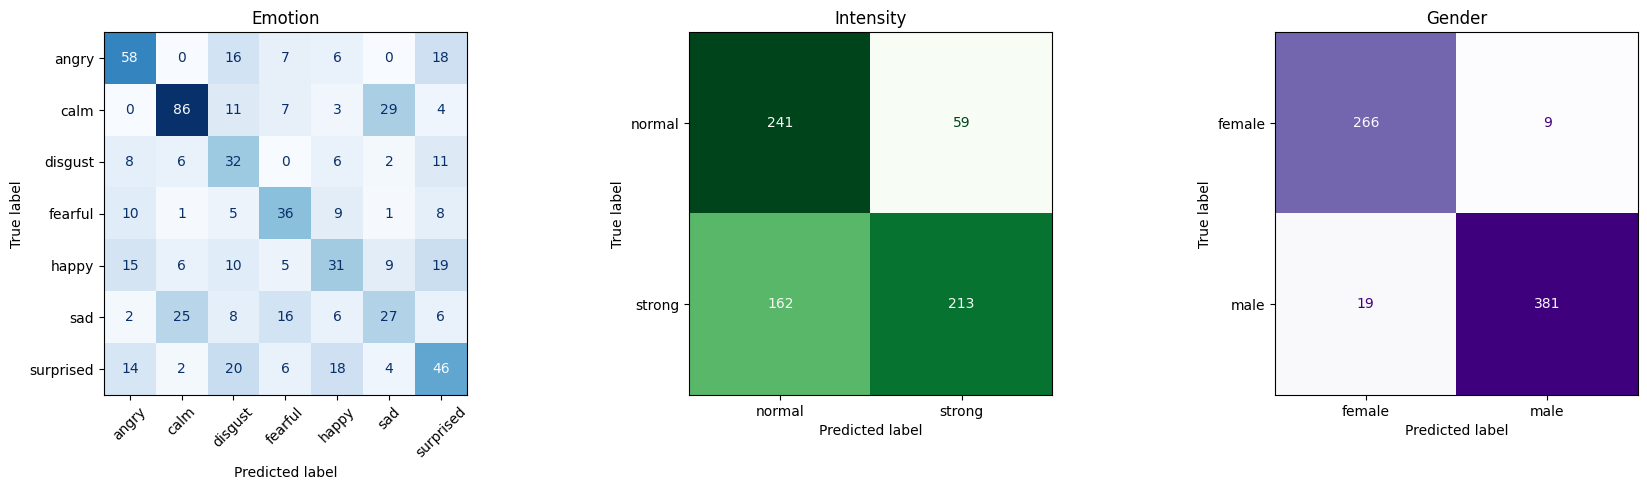

In [6]:
param_grid = {
    "estimator__C":     [0.1, 1, 10],
    "estimator__gamma": ["scale", 0.001, 0.01],
    "estimator__kernel": ['rbf'], 
}

base_svm = MultiOutputClassifier(
    SVC(class_weight="balanced", probability=True)
)

from sklearn.model_selection import GroupKFold
gkf = GroupKFold(n_splits=5)
multi_svm = GridSearchCV(
    base_svm,
    param_grid,
    cv=gkf,
    n_jobs=-1,
    verbose=1,
)

multi_svm.fit(X_train, y_train, groups=groups_train)

joblib.dump(multi_svm, os.path.join("models","svm_multi.pkl"))

print(f"\nBest params: {multi_svm.best_params_}")

y_pred = multi_svm.predict(X_test)

y_emotion_pred = y_pred[:, 0]
y_intensity_pred = y_pred[:, 1]
y_gender_pred = y_pred[:, 2]

y_emotion_test = y_test[:, 0]
y_intensity_test = y_test[:, 1]
y_gender_test = y_test[:, 2]

print("\n" + "=" * 60)
print("EMOTION CLASSIFICATION")
print("=" * 60)
print(classification_report(y_emotion_test, y_emotion_pred, target_names=emotion_encoder.classes_))

print("\n" + "=" * 60)
print("INTENSITY CLASSIFICATION")
print("=" * 60)
print(classification_report(y_intensity_test, y_intensity_pred, target_names=intensity_encoder.classes_))

print("\n" + "=" * 60)
print("GENDER CLASSIFICATION")
print("=" * 60)
print(classification_report(y_gender_test, y_gender_pred, target_names=gender_encoder.classes_))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_emotion = confusion_matrix(y_emotion_test, y_emotion_pred)
ConfusionMatrixDisplay(cm_emotion, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion")

cm_intensity = confusion_matrix(y_intensity_test, y_intensity_pred)
ConfusionMatrixDisplay(cm_intensity, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity")

cm_gender = confusion_matrix(y_gender_test, y_gender_pred)
ConfusionMatrixDisplay(cm_gender, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender")

plt.tight_layout()
plt.show()

In [7]:
scaler = joblib.load(os.path.join("models","svm_scaler.gz"))
emotion_encoder = joblib.load(os.path.join("models","svm_emotion_encoder.pkl"))
intensity_encoder = joblib.load(os.path.join("models","svm_intensity_encoder.pkl"))
gender_encoder = joblib.load(os.path.join("models","svm_gender_encoder.pkl"))

multi_svm = joblib.load(os.path.join("models","svm_multi.pkl"))

In [8]:
import datetime 

with open(f"test_logs/svm_{datetime.datetime.now()}.log","w") as log:
    out = ""
    for (dirp,_,files) in os.walk("sk_test_audios"): 
        files.sort()
        for f in files:
            out += f"\nFile: {f}\n"
            feature = extract_features(os.path.join(dirp,f))
            feature_scaled = scaler.transform([feature])
            predictions = multi_svm.predict(feature_scaled)[0]

            predicted_emotion = emotion_encoder.inverse_transform([predictions[0]])[0]
            predicted_intensity = intensity_encoder.inverse_transform([predictions[1]])[0]
            predicted_gender = gender_encoder.inverse_transform([predictions[2]])[0]

            out += f"\nPredicted Emotion: {predicted_emotion}\n"
            out += f"Predicted Intensity: {predicted_intensity}\n"
            out += f"Predicted Gender: {predicted_gender}\n"
    
    log.write(out)

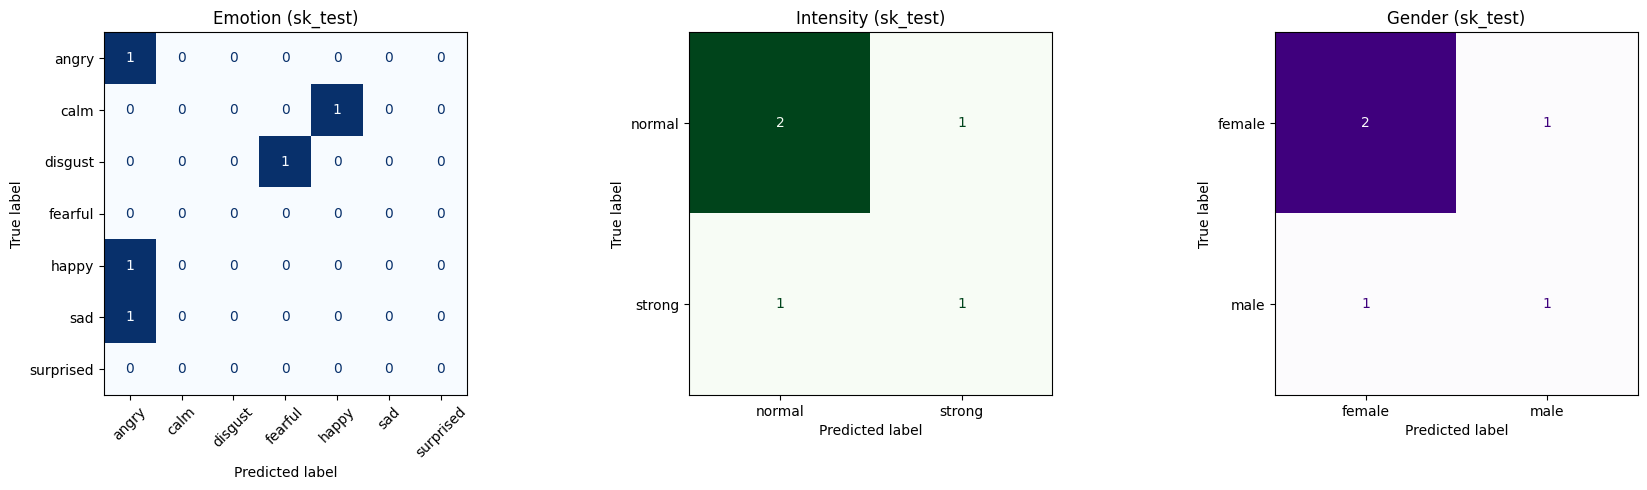


Emotion
              precision    recall  f1-score   support

       angry       0.33      1.00      0.50         1
        calm       0.00      0.00      0.00         1
     disgust       0.00      0.00      0.00         1
     fearful       0.00      0.00      0.00         0
       happy       0.00      0.00      0.00         1
         sad       0.00      0.00      0.00         1
   surprised       0.00      0.00      0.00         0

    accuracy                           0.20         5
   macro avg       0.05      0.14      0.07         5
weighted avg       0.07      0.20      0.10         5


Intensity
              precision    recall  f1-score   support

      normal       0.67      0.67      0.67         3
      strong       0.50      0.50      0.50         2

    accuracy                           0.60         5
   macro avg       0.58      0.58      0.58         5
weighted avg       0.60      0.60      0.60         5


Gender
              precision    recall  f1-score   su

In [9]:
sk_meta = pd.read_csv("sk_test_metadata.csv")

true_emotions, true_intensities, true_genders = [], [], []
pred_emotions, pred_intensities, pred_genders = [], [], []

for _, row in sk_meta.iterrows():
    file_path = os.path.join("sk_test_audios", f"audio{row['AudioID']}.wav")
    feature = extract_features(file_path)
    feature_scaled = scaler.transform([feature])
    preds = multi_svm.predict(feature_scaled)[0]

    true_emotions.append(row["Emotion"].lower())
    true_intensities.append(row["Intensity"].lower())
    true_genders.append(row["Gender"].lower())

    pred_emotions.append(emotion_encoder.inverse_transform([preds[0]])[0])
    pred_intensities.append(intensity_encoder.inverse_transform([preds[1]])[0])
    pred_genders.append(gender_encoder.inverse_transform([preds[2]])[0])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_e = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
ConfusionMatrixDisplay(cm_e, display_labels=emotion_encoder.classes_).plot(
    ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45
)
axes[0].set_title("Emotion (sk_test)")

cm_i = confusion_matrix(true_intensities, pred_intensities, labels=intensity_encoder.classes_)
ConfusionMatrixDisplay(cm_i, display_labels=intensity_encoder.classes_).plot(
    ax=axes[1], cmap="Greens", colorbar=False
)
axes[1].set_title("Intensity (sk_test)")

cm_g = confusion_matrix(true_genders, pred_genders, labels=gender_encoder.classes_)
ConfusionMatrixDisplay(cm_g, display_labels=gender_encoder.classes_).plot(
    ax=axes[2], cmap="Purples", colorbar=False
)
axes[2].set_title("Gender (sk_test)")

plt.tight_layout()
plt.show()

print("\nEmotion")
print(classification_report(true_emotions, pred_emotions,
                             labels=emotion_encoder.classes_,
                             target_names=emotion_encoder.classes_,
                             zero_division=0))
print("\nIntensity")
print(classification_report(true_intensities, pred_intensities,
                             labels=intensity_encoder.classes_,
                             target_names=intensity_encoder.classes_,
                             zero_division=0))
print("\nGender")
print(classification_report(true_genders, pred_genders,
                             labels=gender_encoder.classes_,
                             target_names=gender_encoder.classes_,
                             zero_division=0))
